# Support Vector Machine (SVM)

## 1. Setup

- **Algorithmus:** LinearSVC (scikit-learn)
- **Split:** 80/0/20 (Train / Validation / Test)

In [1]:
import json
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

# ============================================================
# Projektkonfiguration
# ============================================================
PROJECT_ROOT = Path("../")

DATA_DIR   = PROJECT_ROOT / "data" / "splits"
TRAIN_FILE = DATA_DIR / "train_0_50000_80_0_20.jsonl"
TEST_FILE  = DATA_DIR / "test_0_50000_80_0_20.jsonl"

CLASS_NAMES = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

# Datenmenge pro Kategorie aus Split-Dateinamen ableiten
train_n = int(TRAIN_FILE.stem.split("_")[2])
test_n = int(TEST_FILE.stem.split("_")[2])
assert train_n == test_n, f"Unterschiedliche Datenmengen: Train={train_n}, Test={test_n}"
SAMPLES_PER_CAT = train_n
SAMPLE_SUFFIX = f"{SAMPLES_PER_CAT // 1000}k" if SAMPLES_PER_CAT >= 1000 else str(SAMPLES_PER_CAT)

print(f"PROJECT_ROOT: {PROJECT_ROOT.resolve()}")
print(f"TRAIN_FILE existiert: {TRAIN_FILE.exists()}")
print(f"TEST_FILE  existiert: {TEST_FILE.exists()}")
print(f"Datenmenge pro Kategorie: {SAMPLES_PER_CAT:,} ({SAMPLE_SUFFIX})")

PROJECT_ROOT: C:\Develop\Python\nlp
TRAIN_FILE existiert: True
TEST_FILE  existiert: True
Datenmenge pro Kategorie: 50,000 (50k)


## 2. Hyperparameter
| Parameter | Beschreibung | Typische Werte |
|---|---|---|
| `C` | Regularisierungsstärke (LinearSVC) | 0.01 – 10.0 |
| `MAX_ITER` | Max. Iterationen (LinearSVC) | 1000 – 5000 |
| `MAX_FEATURES` | Max. Anzahl TF-IDF-Features | 1.000 – 100.000 |
| `MIN_DF` | Min. Dokumenthäufigkeit eines Terms | 1 – 10 |
| `MAX_DF` | Max. Dokumenthäufigkeit eines Terms | 0.7 – 1.0 |
| `NGRAM_RANGE` | Uni- und/oder Bigramme | (1,1), (1,2) |
| `STOP_WORDS` | Stoppwörter entfernen | 'english', None |
| `SUBLINEAR_TF` | Logarithmische TF-Skalierung | True, False |

In [2]:
# ============================================================
# HYPERPARAMETER – hier anpassen!
# ============================================================

# LinearSVC
C        = 1.0      # Regularisierungsstärke; kleiner = stärkere Regularisierung
MAX_ITER = 2000     # Max. Iterationen bis zur Konvergenz

# TF-IDF Vektorizer
MAX_FEATURES = 10000    # Anzahl der Features (Vokabular-Größe)
MIN_DF       = 2        # Term muss in mind. N Dokumenten vorkommen
MAX_DF       = 0.95     # Term darf in höchstens X% der Dokumente vorkommen
NGRAM_RANGE  = (1, 2)   # (1,1) = Unigramme; (1,2) = Uni- + Bigramme
STOP_WORDS   = 'english'  # Stoppwörter: 'english' oder None
SUBLINEAR_TF = False    # True = log(TF) statt TF; oft besser bei langen Texten

print("Aktuelle Hyperparameter:")
print(f"  C            = {C}")
print(f"  MAX_ITER     = {MAX_ITER}")
print(f"  MAX_FEATURES = {MAX_FEATURES}")
print(f"  MIN_DF       = {MIN_DF}")
print(f"  MAX_DF       = {MAX_DF}")
print(f"  NGRAM_RANGE  = {NGRAM_RANGE}")
print(f"  STOP_WORDS   = {STOP_WORDS}")
print(f"  SUBLINEAR_TF = {SUBLINEAR_TF}")

Aktuelle Hyperparameter:
  C            = 1.0
  MAX_ITER     = 2000
  MAX_FEATURES = 10000
  MIN_DF       = 2
  MAX_DF       = 0.95
  NGRAM_RANGE  = (1, 2)
  STOP_WORDS   = english
  SUBLINEAR_TF = False


## 3. Trainingsdaten laden

In [3]:
def load_data(filepath):
    """Lädt JSONL-Datei und kombiniert title + text."""
    texts, ratings = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            texts.append(f"{data['title']} {data['text']}")
            ratings.append(int(data['rating']))
    return texts, ratings

print("Lade Trainingsdaten ...")
X_train_texts, y_train = load_data(TRAIN_FILE)
print(f"  Train:      {len(X_train_texts):>7,} Samples")

print("Lade Testdaten ...")
X_test_texts, y_test = load_data(TEST_FILE)
print(f"  Test:       {len(X_test_texts):>7,} Samples")

Lade Trainingsdaten ...
  Train:      160,000 Samples
Lade Testdaten ...
  Test:        40,000 Samples


## 4. Klassenverteilung prüfen

In [4]:
# Class Distribution
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

print("\nTraining Set Distribution:")
print(train_dist)
print(f"\nTest Set Distribution:")
print(test_dist)


Training Set Distribution:
1      9732
2      6861
3     13470
4     26824
5    103113
Name: count, dtype: int64

Test Set Distribution:
1     2600
2     1634
3     3159
4     6145
5    26462
Name: count, dtype: int64


## 5. TF-IDF Vektorisierung

In [5]:
print("Vektorisierung (TF-IDF) ...")
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    lowercase=True,
    stop_words=STOP_WORDS,
    ngram_range=NGRAM_RANGE,
    sublinear_tf=SUBLINEAR_TF
)

X_train = vectorizer.fit_transform(X_train_texts)
X_test  = vectorizer.transform(X_test_texts)

print(f"✓ Feature-Dimension: {X_train.shape[1]:,}")
print(f"✓ Train-Matrix:      {X_train.shape}")
print(f"✓ Test-Matrix:       {X_test.shape}")

Vektorisierung (TF-IDF) ...
✓ Feature-Dimension: 10,000
✓ Train-Matrix:      (160000, 10000)
✓ Test-Matrix:       (40000, 10000)


## 6. Training

In [7]:
print("Trainiere LinearSVC ...")
model = LinearSVC(
    C=C,
    max_iter=MAX_ITER,
    random_state=42
)
model.fit(X_train, y_train)
print("✓ Training abgeschlossen")

Trainiere LinearSVC ...
✓ Training abgeschlossen


## 7. Evaluierung

In [8]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"{'='*60}")
print(f"TEST-EVALUIERUNG")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

TEST-EVALUIERUNG
Accuracy: 0.7217

Confusion Matrix:
[[ 1654   139   168    82   557]
 [  452   170   343   146   523]
 [  282   155   787   536  1399]
 [  107    55   365  1047  4571]
 [  144    60   217   831 25210]]

Classification Report:
              precision    recall  f1-score   support

      1 Star       0.63      0.64      0.63      2600
     2 Stars       0.29      0.10      0.15      1634
     3 Stars       0.42      0.25      0.31      3159
     4 Stars       0.40      0.17      0.24      6145
     5 Stars       0.78      0.95      0.86     26462

    accuracy                           0.72     40000
   macro avg       0.50      0.42      0.44     40000
weighted avg       0.66      0.72      0.68     40000



## 8. Ergebnisse speichern

Run-Verzeichnis: ..\results\svm\runs\run_02_50k


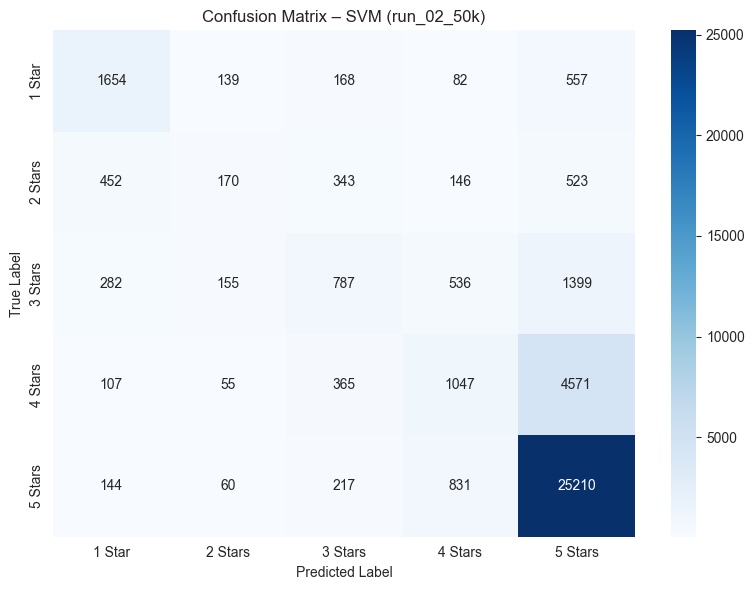

✓ Metriken, Modell und Confusion Matrix in ..\results\svm\runs\run_02_50k
✓ Overview aktualisiert: ..\results\svm\runs\overview.csv


In [10]:
# ============================================================
# Run-Verzeichnis ermitteln
# ============================================================
RUNS_DIR = PROJECT_ROOT / "results" / "svm" / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

existing_runs = [d.name for d in RUNS_DIR.iterdir() if d.is_dir() and d.name.startswith("run_")]
if existing_runs:
    max_num = max(int(name.split("_")[1]) for name in existing_runs)
    run_num = max_num + 1
else:
    run_num = 1

run_name = f"run_{run_num:02d}_{SAMPLE_SUFFIX}"
RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run-Verzeichnis: {RUN_DIR}")

# ============================================================
# Metriken speichern
# ============================================================
results = {
    'run': run_name,
    'accuracy': float(accuracy),
    'num_train_samples': len(y_train),
    'num_test_samples': len(y_test),
    'train_file': TRAIN_FILE.name,
    'test_file': TEST_FILE.name,
    'classes': CLASS_NAMES,
    'hyperparameters': {
        'C': C,
        'max_iter': MAX_ITER,
        'max_features': MAX_FEATURES,
        'min_df': MIN_DF,
        'max_df': MAX_DF,
        'ngram_range': list(NGRAM_RANGE),
        'stop_words': STOP_WORDS,
        'sublinear_tf': SUBLINEAR_TF
    }
}
with open(RUN_DIR / "metrics.json", 'w') as f:
    json.dump(results, f, indent=2)

# Modell + Vectorizer
with open(RUN_DIR / "model.pkl", 'wb') as f:
    pickle.dump(model, f)
with open(RUN_DIR / "vectorizer.pkl", 'wb') as f:
    pickle.dump(vectorizer, f)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix – SVM ({run_name})')
plt.tight_layout()
plt.savefig(RUN_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# Overview-CSV aktualisieren
hyperparams_str = (
    f"C: {C} | max_iter: {MAX_ITER} | max_features: {MAX_FEATURES} | min_df: {MIN_DF} | "
    f"max_df: {MAX_DF} | ngram_range: {NGRAM_RANGE} | stop_words: {STOP_WORDS} | "
    f"sublinear_tf: {SUBLINEAR_TF}"
)
row = pd.DataFrame({
    'Run':             [run_name],
    'Accuracy':        [accuracy],
    'Train_Samples':   [len(y_train)],
    'Test_Samples':    [len(y_test)],
    'Hyperparameters': [hyperparams_str]
})

overview_path = RUNS_DIR / "overview.csv"
if overview_path.exists():
    existing = pd.read_csv(overview_path, sep=';')
    overview = pd.concat([existing, row], ignore_index=True)
else:
    overview = row
overview.to_csv(overview_path, index=False, sep=';')

print(f"✓ Metriken, Modell und Confusion Matrix in {RUN_DIR}")
print(f"✓ Overview aktualisiert: {overview_path}")

### Confusion Matrix – Interpretation

**Struktur:**
- Zeilen = True Label (tatsächliche Klasse)
- Spalten = Predicted Label (vom Modell vorhergesagte Klasse)

**Für jede Klasse (Beispiel: "5 Stars"):**

**TP (True Positives) – Diagonale:** Korrekt als diese Klasse vorhergesagt.

**FP (False Positives) – Spalte (ohne Diagonale):** Fälschlicherweise als diese Klasse klassifiziert.

**FN (False Negatives) – Zeile (ohne Diagonale):** Gehört zu dieser Klasse, wurde aber falsch klassifiziert.

**TN (True Negatives):** Alles außerhalb der Zeile und Spalte dieser Klasse.